<a href="https://colab.research.google.com/github/otwn/Data-Science-Review/blob/master/sklearn/Module7_evaluating_model_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall scikit-learn
!pip install scikit-learn

Uninstalling scikit-learn-0.22.2.post1:
  Would remove:
    /usr/local/lib/python3.7/dist-packages/scikit_learn-0.22.2.post1.dist-info/*
    /usr/local/lib/python3.7/dist-packages/sklearn/*
Proceed (y/n)? y
  Successfully uninstalled scikit-learn-0.22.2.post1
     |████████████████████████████████| 22.3MB 4.2MB/s 


In [ ]:
import sklearn
sklearn.__version__

'0.24.2'

In [ ]:
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/scikit-learn-mooc/scikit-learn-mooc-master")
os.listdir()

['README.md',
 '.github',
 'python_scripts',
 'requirements.txt',
 '.binder',
 '.circleci',
 'notebooks',
 'plan.md',
 'jupyter-book',
 'figures',
 'local-install-instructions.md',
 'requirements-dev.txt',
 'slides',
 'build_tools',
 'LICENSE',
 '.gitignore',
 'index.md',
 'Makefile',
 'environment.yml',
 'environment-dev.yml',
 '.jupyter',
 'CONTRIBUTING.md',
 'datasets',
 'check_env.py']

# Comparing results with baseline and chance level

In [ ]:
from sklearn.datasets import fetch_california_housing

data, target = fetch_california_housing(return_X_y=True, as_frame=True)
target *= 100

In [ ]:
from sklearn.model_selection import ShuffleSplit 

cv = ShuffleSplit(n_splits=30, test_size=0.2, random_state=0)

In [ ]:
import pandas as pd 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.model_selection import cross_validate

regressor = DecisionTreeRegressor()
result_regressor = cross_validate(regressor, data, target,
                                  cv=cv, scoring="neg_mean_absolute_error",
                                  n_jobs=-1)
errors_regressor = pd.Series(-result_regressor["test_score"],
                             name="Regressor error")

Then, we will evaluate our first baseline. This baseline is called a dummy regressor. This dummy regressor will always predict the mean target computed on the training. Therefore, the dummy regressor will never use any information regarding the data data.

In [ ]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor()
result_dummy = cross_validate(dummy, data, target,
                              cv=cv, scoring="neg_mean_absolute_error",
                              n_jobs=-1)
error_dummy = pd.Series(-result_dummy["test_score"], name="Dummy error")

Finally, we will evaluate the statistical performance of the second baseline. This baseline will provide the statistical performance of the chance level. Indeed, we will train a decision tree on some training data and evaluate the same tree on data where the target vector has been randomized.

In [ ]:
from sklearn.model_selection import permutation_test_score
regressor = DecisionTreeRegressor()
score, permutation_score, pvalue = permutation_test_score(
    regressor, data, target, cv=cv, scoring="neg_mean_absolute_error",
    n_jobs=-1, n_permutations=30
)
errors_permutation = pd.Series(-permutation_score, name="Permuted error")

In [ ]:
final_errors = pd.concat([errors_regressor, error_dummy, errors_permutation], axis=1)

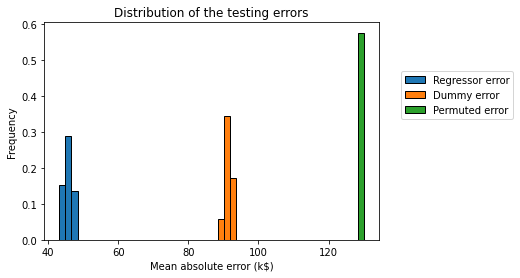

In [ ]:
import matplotlib.pyplot as plt 

final_errors.plot.hist(bins=50, density=True, edgecolor="black")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.xlabel("Mean absolute error (k$)")
_ = plt.title("Distribution of the testing errors")

We see that even if the statistical performance of our model is far from being good, it is better than the two baselines. Besides, we see that the dummy regressor is better than a chance level regressor.

In practice, using a dummy regressor might be sufficient as a baseline. Indeed, to obtain a reliable estimate the permutation of the target should be repeated and thus this method is costly. However, it gives the true chance level.

# Exercise M7.01

In [ ]:
import pandas as pd 
adult_census = pd.read_csv("./datasets/adult-census-numeric-all.csv")
data, target = adult_census.drop(columns="class"), adult_census["class"]


First, define a ShuffleSplit cross-validation strategy taking half of the sample as a testing at each round.

In [ ]:
from sklearn.model_selection import ShuffleSplit 

cv = ShuffleSplit(n_splits=10, test_size=0.5, random_state=0)

In [ ]:
from sklearn.pipeline import make_pipeline 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

classifier = make_pipeline(StandardScaler(), LogisticRegression())


In [ ]:
from sklearn.model_selection import cross_validate 

result_classifier = cross_validate(classifier, data, target, cv=cv, n_jobs=2)

test_score_classifier = pd.Series(result_classifier["test_score"], name="Classifier score")

In [ ]:
test_score_classifier.mean()

0.8138323573973218

In [ ]:
from sklearn.model_selection import permutation_test_score

score, permutation_score, pvalue = permutation_test_score(
    classifier, data, target, cv=cv, n_jobs=2, n_permutations=10
)
test_score_permutation = pd.Series(permutation_score, name="Permuted score")

In [ ]:
test_score_permutation.mean()

0.7609500020474181

In [ ]:
from sklearn.dummy import DummyClassifier 

dummy = DummyClassifier(strategy="most_frequent")
result_dummy = cross_validate(dummy, data, target, cv=cv, n_jobs=2)
test_score_dummy = pd.Series(result_dummy["test_score"], name="Dummy score")

In [ ]:
test_score_dummy.mean()

0.7600221121166209

In [ ]:
final_test_scores = pd.concat(
    [test_score_classifier, test_score_permutation, test_score_dummy],
    axis=1,
)

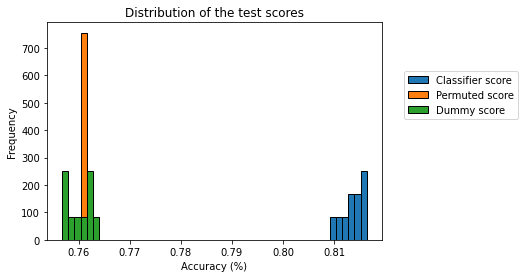

In [ ]:
import matplotlib.pyplot as plt 

final_test_scores.plot.hist(bins=50, density=True, edgecolor="black")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.xlabel("Accuracy (%)")
_ = plt.title("Distribution of the test scores")

We observe that the dummy classifier with the strategy most_frequent is equivalent to the permutation score. We can also conclude that our model is better than the other baseline.

Change the strategy of the dummy classifier to stratified, compute the results and plot the distribution together with the other results. Explain why the results get worse.

In [ ]:
dummy = DummyClassifier(strategy="stratified")
result_dummy_stratify = cross_validate(dummy, data, target, cv=cv, n_jobs=2)
test_score_dummy_stratify = pd.Series(
    result_dummy_stratify["test_score"], name="Dummy 'stratify' score")

final_test_scores = pd.concat(
    [
     test_score_classifier, test_score_permutation,
     test_score_dummy, test_score_dummy_stratify
    ],
    axis=1
)

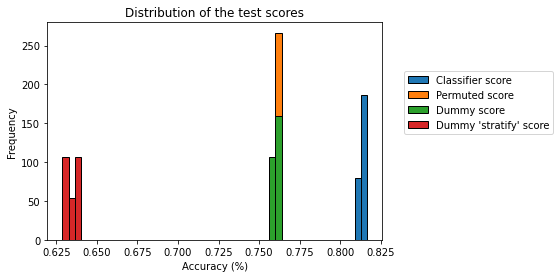

In [ ]:
final_test_scores.plot.hist(bins=50, density=True, edgecolor="black")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.xlabel("Accuracy (%)")
_ = plt.title("Distribution of the test scores")

We see that using strategy="stratified", the results are much worse than with the most_frequent strategy. Since the classes are imbalanced, predicting the most frequent involves that we will be right for the proportion of this class (~75% of the samples). However, by using the stratified strategy, wrong predictions will be made even for the most frequent class, hence we obtain a lower accuracy.

# Introductory exercise regarding stratification

The goal of this exercise is to highlight one limitation of
applying blindly a k-fold cross-validation.

In [ ]:
from sklearn.datasets import load_iris 

data, target = load_iris(return_X_y=True, as_frame=True)

# Stratification

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(), LogisticRegression())

Once we created our model, we will use the cross-validation framework to evaluate it. We will use the KFold cross-validation strategy. We will define a dataset with nine samples and repeat the cross-validation three times (i.e. n_splits).

In [ ]:
import numpy as np 
from sklearn.model_selection import KFold 

data_random = np.random.randn(9,1)
cv = KFold(n_splits=3)
for train_index, test_index in cv.split(data_random):
  print("TRAIN:", train_index, "TEST:", test_index)

TRAIN: [3 4 5 6 7 8] TEST: [0 1 2]
TRAIN: [0 1 2 6 7 8] TEST: [3 4 5]
TRAIN: [0 1 2 3 4 5] TEST: [6 7 8]


By defining three splits, we will use three samples for testing and six for training each time. KFold does not shuffle by default. It means that it will select the three first samples for the testing set at the first split, then the three next three samples for the second split, and the three next for the last split. In the end, all samples have been used in testing at least once among the different splits.

In [ ]:
from sklearn.model_selection import cross_validate 

cv = KFold(n_splits=3)
results = cross_validate(model, data, target, cv=cv)
test_score = results["test_score"]
print(f"The average accuracy is "
      f"{test_score.mean():.3f} +/- {test_score.std():.3f}")

The average accuracy is 0.000 +/- 0.000


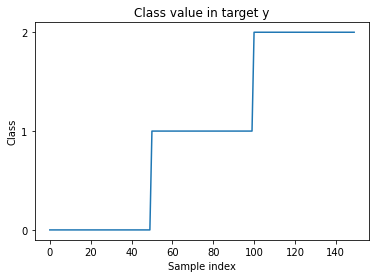

In [ ]:
import matplotlib.pyplot as plt 

target.plot()
plt.xlabel("Sample index")
plt.ylabel("Class")
plt.yticks(target.unique())
_ = plt.title("Class value in target y")

We see that the target vector target is ordered. It will have some unexpected consequences when using the KFold cross-validation. To illustrate the consequences, we will show the class count in each fold of the cross-validation in the train and test set.

Let's compute the class counts for both the training and testing sets using the KFold cross-validation, and plot these information in a bar plot.

We will iterate given the number of split and check how many samples of each are present in the training and testing set. We will store the information into two distincts lists; one for the training set and one for the testing set.

In [ ]:
import pandas as pd 

n_splits = 3 
cv = KFold(n_splits=n_splits)

train_cv_counts = []
test_cv_counts = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(data, target)):
  target_train, target_test = target.iloc[train_idx], target.iloc[test_idx]
  train_cv_counts.append(target_train.value_counts())
  test_cv_counts.append(target_test.value_counts())

In [ ]:
train_cv_counts = pd.concat(train_cv_counts, axis=1,
                            keys=[f"Fold #{idx}" for idx in range(n_splits)])
train_cv_counts.index.name = "Class label"
train_cv_counts

,Fold #0,Fold #1,Fold #2
Class label,,,
0,NaN,50.0,50.0
1,50.0,NaN,50.0
2,50.0,50.0,NaN


In [ ]:
test_cv_counts = pd.concat(test_cv_counts, axis=1,
                           keys=[f"Fold #{idx}" for idx in range(n_splits)])
test_cv_counts.index.name = "Class label"
test_cv_counts

,Fold #0,Fold #1,Fold #2
Class label,,,
0,50.0,NaN,NaN
1,NaN,50.0,NaN
2,NaN,NaN,50.0


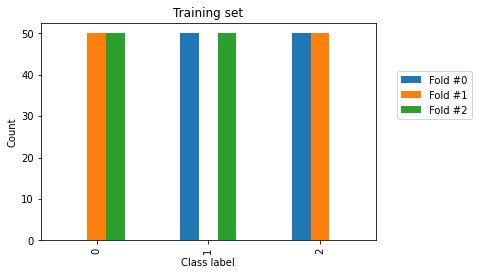

In [ ]:
train_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Training set")

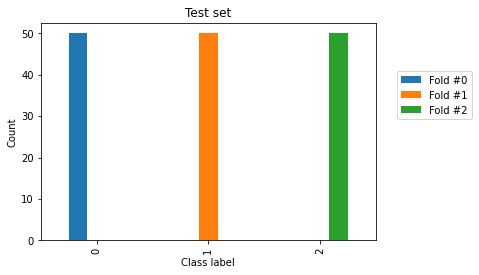

In [ ]:
test_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Test set")

We can confirm that in each fold, only two of the three classes are present in the training set and all samples of the remaining class is used as a test set. So our model is unable to predict this class that was unseen during the training stage.

One possibility to solve the issue is to shuffle the data before splitting the data into three groups.

In [ ]:
cv = KFold(n_splits=3, shuffle=True, random_state=0)
results = cross_validate(model, data, target, cv=cv)
test_score = results["test_score"]
print(f"The average accuracy is "
      f"{test_score.mean():.3f} +/- {test_score.std():.3f}")

The average accuracy is 0.953 +/- 0.009


We get results that are closer to what we would expect with an accuracy above 90%. Now that we solved our first issue, it would be interesting to check if the class frequency in the training and testing set is equal to our original set's class frequency. It would ensure that we are training and testing our model with a class distribution that we will encounter in production.

In [ ]:
train_cv_counts = []
test_cv_counts = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(data, target)):
  target_train, target_test = target.iloc[train_idx], target.iloc[test_idx]
  train_cv_counts.append(target_train.value_counts())
  test_cv_counts.append(target_test.value_counts())

train_cv_counts = pd.concat(train_cv_counts, axis=1, 
                            keys=[f"Fold #{idx}" for idx in range(n_splits)])
test_cv_counts = pd.concat(test_cv_counts, axis=1,
                           keys=[f"Fold #{idx}" for idx in range(n_splits)])
train_cv_counts.index.name = "Class label"
test_cv_counts.index.name = "Class label"

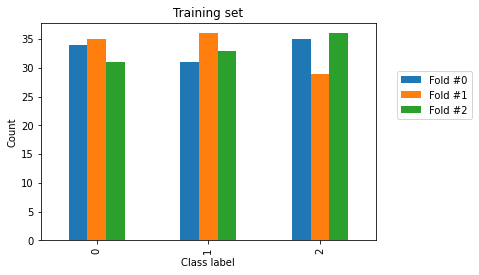

In [ ]:
train_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Training set")

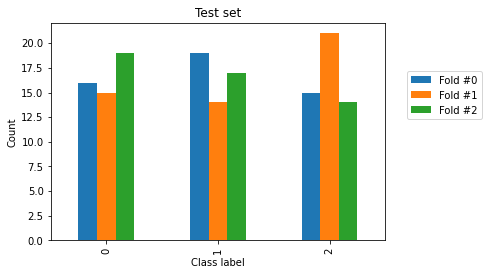

In [ ]:
test_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Test set")

We see that neither the training and testing sets have the same class frequencies as our original dataset because the count for each class is varying a little.

However, one might want to split our data by preserving the original class frequencies: we want to stratify our data by class. In scikit-learn, some cross-validation strategies implement the stratification; they contain Stratified in their names.

In [ ]:
from sklearn.model_selection import StratifiedKFold 

cv = StratifiedKFold(n_splits=3) # this is the only difference

In [ ]:
results = cross_validate(model, data, target, cv=cv) # cv is different
test_score = results["test_score"]
print(f"The average accuracy is "
      f"{test_score.mean():.3f} +/- {test_score.std():.3f}")

The average accuracy is 0.960 +/- 0.016


In [ ]:
train_cv_counts = []
test_cv_counts = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(data, target)):
    target_train, target_test = target.iloc[train_idx], target.iloc[test_idx]

    train_cv_counts.append(target_train.value_counts())
    test_cv_counts.append(target_test.value_counts())
train_cv_counts = pd.concat(train_cv_counts, axis=1,
                            keys=[f"Fold #{idx}" for idx in range(n_splits)])
test_cv_counts = pd.concat(test_cv_counts, axis=1,
                           keys=[f"Fold #{idx}" for idx in range(n_splits)])
train_cv_counts.index.name = "Class label"
test_cv_counts.index.name = "Class label"

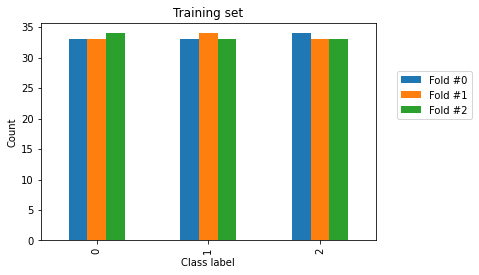

In [ ]:
train_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Training set")

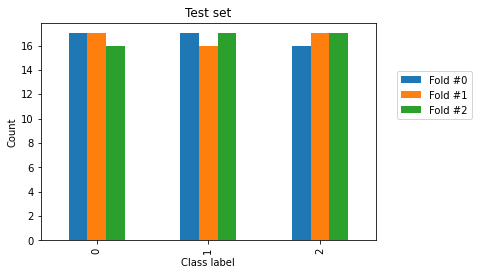

In [ ]:
test_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Test set")

# Sample grouping

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits() 
data, target = digits.data, digits.target

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(), LogisticRegression())

In [ ]:
from sklearn.model_selection import cross_val_score, KFold 
cv = KFold(shuffle=False)
test_score_no_shuffling = cross_val_score(model, data, target, cv=cv,
                                          n_jobs=-1)
print(f"The average accuracy is "
      f"{test_score_no_shuffling.mean():.3f} +/- "
      f"{test_score_no_shuffling.std():.3f}")

The average accuracy is 0.921 +/- 0.028


In [ ]:
cv = KFold(shuffle=True)
test_score_with_shuffling = cross_val_score(model, data, target, cv=cv,
                                          n_jobs=-1)
print(f"The average accuracy is "
      f"{test_score_with_shuffling.mean():.3f} +/- "
      f"{test_score_with_shuffling.std():.3f}")

The average accuracy is 0.968 +/- 0.009


We observe that shuffling the data improves the mean accuracy. We could go a little further and plot the distribution of the testing score. We can first concatenate the test scores.

In [ ]:
import pandas as pd 
all_scores = pd.DataFrame(
    [test_score_no_shuffling, test_score_with_shuffling],
    index=["KFold without shuffling", "KFold with shuffling"]
).T

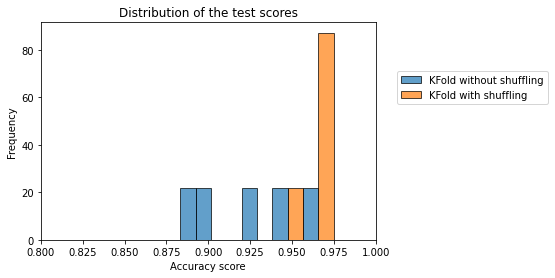

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

all_scores.plot.hist(bins=10, edgecolor="black", density=True, alpha=0.7)
plt.xlim([0.8, 1.0])
plt.xlabel("Accuracy score")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Distribution of the test scores")

In [ ]:
print(test_score_no_shuffling)

[0.92222222 0.88333333 0.94150418 0.96100279 0.89693593]


In [ ]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 1797
    :Number of Attributes: 64
    :Attribute Information: 8x8 image of integer pixels in the range 0..16.
    :Missing Attribute Values: None
    :Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
    :Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each blo

In [ ]:
from itertools import count 
import numpy as np 

# defines the lower and upper bounds of sample indices
# for each writer
writer_boundaries = [0, 130, 256, 386, 516, 646, 776, 915, 1029,
                     1157, 1287, 1415, 1545, 1667, 1797]
groups = np.zeros_like(target)
lower_bounds = writer_boundaries[:-1]
upper_bounds = writer_boundaries[1:]

for group_id, lb, up in zip(count(), lower_bounds, upper_bounds):
  groups[lb:up] = group_id

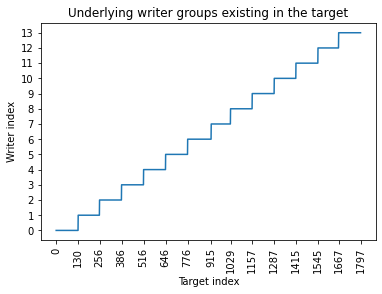

In [ ]:
plt.plot(groups)
plt.yticks(np.unique(groups))
plt.xticks(writer_boundaries, rotation=90)
plt.xlabel("Target index")
plt.ylabel("Writer index")
_ = plt.title("Underlying writer groups existing in the target")

In [ ]:
from sklearn.model_selection import GroupKFold 
cv = GroupKFold()
test_score = cross_val_score(model, data, target, cv=cv,
                             groups=groups, n_jobs=-1)
print(f"Teh average accuracy is "
      f"{test_score.mean():.3f} +/- "
      f"{test_score.std():.3f}")

Teh average accuracy is 0.919 +/- 0.015


In [ ]:
all_scores = pd.DataFrame(
    [test_score_no_shuffling, test_score_with_shuffling, test_score],
    index=["KFold without shuffling", "KFold with shuffling", "KFold with groups"]
).T

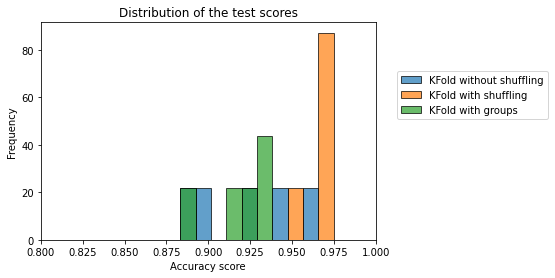

In [ ]:
all_scores.plot.hist(bins=10, edgecolor="black", density=True, alpha=0.7)
plt.xlim([0.8, 1.0])
plt.xlabel("Accuracy score")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Distribution of the test scores")

# Non i.i.d. data

In machine learning, it is quite common to assume that the data are i.i.d, meaning that the generative process does not have any memory of past samples to generate new samples.

This assumption is usually violated when dealing with time series. A sample depends on past information.

We will take an example to highlight such issues with non-i.i.d. data in the previous cross-validation strategies presented. We are going to load financial quotations from some energy companies.

In [ ]:
import pandas as pd


symbols = {"TOT": "Total", "XOM": "Exxon", "CVX": "Chevron",
           "COP": "ConocoPhillips", "VLO": "Valero Energy"}
url = ("https://raw.githubusercontent.com/scikit-learn/examples-data/"
       "master/financial-data/{}.csv")

quotes = {}
for symbol in symbols:
  data = pd.read_csv(url.format(symbol), index_col=0, parse_dates=True)
  quotes[symbols[symbol]] = data["open"]
quotes = pd.DataFrame(quotes)

In [ ]:
quotes.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2003-01-02 to 2007-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Total           1258 non-null   float64
 1   Exxon           1258 non-null   float64
 2   Chevron         1258 non-null   float64
 3   ConocoPhillips  1258 non-null   float64
 4   Valero Energy   1258 non-null   float64
dtypes: float64(5)
memory usage: 59.0 KB


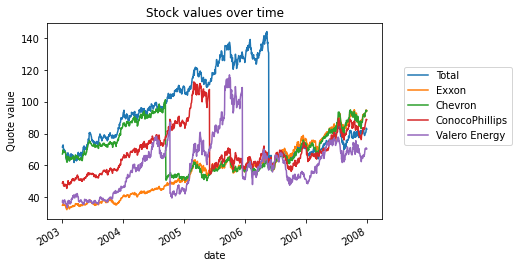

In [ ]:
import matplotlib.pyplot as plt 
quotes.plot()
plt.ylabel("Quote value")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Stock values over time")

In [ ]:
from sklearn.model_selection import train_test_split

data, target = quotes.drop(columns=["Chevron"]), quotes["Chevron"]
data_train, data_test, target_train, target_test = train_test_split(
    data, target, shuffle=True, random_state=0
)

In [ ]:
from sklearn.tree import DecisionTreeRegressor 
from sklearn.model_selection import ShuffleSplit, cross_val_score

regressor = DecisionTreeRegressor()
cv = ShuffleSplit(random_state=0)

test_score = cross_val_score(
    regressor, data_train, target_train, cv=cv, n_jobs=-1
)

In [ ]:
print(f"The mean R2 is: "
      f"{test_score.mean():.2f} +/- {test_score.std():.2f}")

The mean R2 is: 0.95 +/- 0.07


Surprisingly, we get outstanding statistical performance. We will investigate and find the reason for such good results with a model that is expected to fail. We previously mentioned that ShuffleSplit is an iterative cross-validation scheme that shuffles data and split. We will simplify this procedure with a single split and plot the prediction. We can use train_test_split for this purpose.

In [ ]:
regressor.fit(data_train, target_train)
target_predicted = regressor.predict(data_test)
# affect the index of `target_predicted` to ease the plotting
target_predicted = pd.Series(target_predicted, index=target_test.index)

In [ ]:
from sklearn.metrics import r2_score 
test_score = r2_score(target_test, target_predicted)
print(f"The R2 on this single split is: {test_score:.2f}")

The R2 on this single split is: 0.83


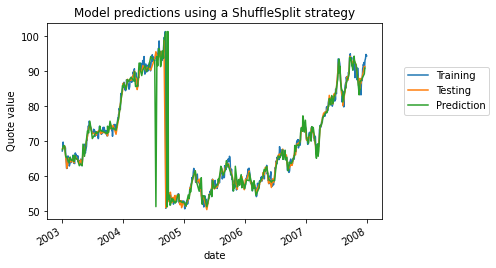

In [ ]:
target_train.plot(label="Training")
target_test.plot(label="Testing")
target_predicted.plot(label="Prediction")

plt.ylabel("Quote value")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Model predictions using a ShuffleSplit strategy")

we can also see that the testing samples are next to some training sample. And with these time-series, we see a relationship between a sample at the time t and a sample at t+1. In this case, we are violating the i.i.d. assumption. The insight to get is the following: a model can output of its training set at the time t for a testing sample at the time t+1. This prediction would be close to the true value even if our model did not learn anything, but just memorized the training dataset.

In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, shuffle=False, random_state=0
)
regressor.fit(data_train, target_train)
target_predicted = regressor.predict(data_test)
target_predicted = pd.Series(target_predicted, index=target_test.index)

In [ ]:
test_score = r2_score(target_test, target_predicted)
print(f"The R2 on this single split is: {test_score:.2f}")

The R2 on this single split is: -2.16


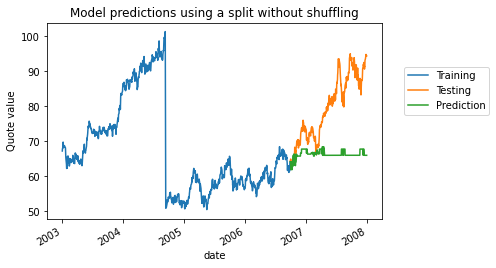

In [ ]:
target_train.plot(label="Training")
target_test.plot(label="Testing")
target_predicted.plot(label="Prediction")

plt.ylabel("Quote value")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Model predictions using a split without shuffling")

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut 

groups = quotes.index.to_period("Q")
cv = LeaveOneGroupOut()
test_score = cross_val_score(
    regressor, data, target, cv=cv,
    groups=groups, n_jobs=-1
)
print(f"The mean R2 is: "
      f"{test_score.mean():.2f} +/- {test_score.std():.2f}")

The mean R2 is: -0.92 +/- 1.69


nother thing to consider is the actual application of our solution. If our model is aimed at forecasting (i.e., predicting future data from past data), we should not use training data that are ulterior to the testing data. In this case, we can use the TimeSeriesSplit cross-validation to enforce this behaviour.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit 

cv = TimeSeriesSplit(n_splits=groups.nunique())
test_score = cross_val_score(regressor, data, target,
                             cv=cv, groups=groups, n_jobs=-1)
print(f"The mean R2 is: "
      f"{test_score.mean():.2f} +/- {test_score.std():.2f}")

The mean R2 is: -6.00 +/- 16.73


# Nested cross-validation

nested cross-validation which should be used when you want to both evaluate a model and tune the model's hyperparameters.

In [ ]:
from sklearn.datasets import load_breast_cancer 

data, target = load_breast_cancer(return_X_y=True)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC 

param_grid = {"C":[0.1, 1, 10], "gamma": [.01, .1]}
model_to_tune = SVC()

gscv = GridSearchCV(estimator=model_to_tune, param_grid=param_grid, n_jobs=-1)
gscv.fit(data, target)

GridSearchCV(estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.01, 0.1]})

In [ ]:
print(f"The best parameter found are: {gscv.best_params_}")

The best parameter found are: {'C': 0.1, 'gamma': 0.01}


In [ ]:
print(f"The mean score in CV is: {gscv.best_score_:.3f}")

The mean score in CV is: 0.627


At this stage, one should be extremely careful using this score. The misinterpretation would be the following: since the score was computed on a test set, it could be considered our model's testing score.

However, we should not forget that we used this score to pick-up the best model. It means that we used knowledge from the test set (i.e. test score) to decide our model's training parameter.

Thus, this score is not a reasonable estimate of our testing error. Indeed, we can show that it will be too optimistic in practice. The good way is to use a "nested" cross-validation. We will use an inner cross-validation corresponding to the previous procedure shown to optimize the hyperparameters. We will also include this procedure within an outer cross-validation, which will be used to estimate the testing error of our tuned model.

In this case, our inner cross-validation will always get the training set of the outer cross-validation, making it possible to compute the testing score on a completely independent set.



In [ ]:
from sklearn.model_selection import cross_val_score, KFold 

# declare the inner and outer cross-validation
inner_cv = KFold(n_splits=4, shuffle=True, random_state=0)
outer_cv = KFold(n_splits=4, shuffle=True, random_state=0)

# Inner cross-validation for parameter search
model =GridSearchCV(
    estimator=model_to_tune, param_grid=param_grid, cv=inner_cv, n_jobs=-1
)
# Outer cross-validationto compute the testing score
test_score = cross_val_score(model, data, target, cv=outer_cv, n_jobs=-1)
print(f"The mean score using nested cross-validation is: "
      f"{test_score.mean():.3f} +/- {test_score.std():.3f}")

The mean score using nested cross-validation is: 0.627 +/- 0.021


In [ ]:
test_score_not_nested = []
test_score_nested = []

N_TRIALS=20

for i in range(N_TRIALS):
  inner_cv = KFold(n_splits=4, shuffle=True, random_state=i)
  outer_cv = KFold(n_splits=4, shuffle=True, random_state=i)

  # Non_nested parameter search and scoring
  model = GridSearchCV(estimator=model_to_tune, param_grid=param_grid,
                       cv=inner_cv, n_jobs=-1)
  model.fit(data, target)
  test_score_not_nested.append(model.best_score_)

  # Nested CV with parameter optimization
  test_score = cross_val_score(model, data, target, cv=outer_cv, n_jobs=-1)
  test_score_nested.append(test_score.mean())

In [ ]:
import pandas as pd 
all_scores = {
    "Not nested CV": test_score_not_nested,
    "Nested CV": test_score_nested
}
all_scores = pd.DataFrame(all_scores)

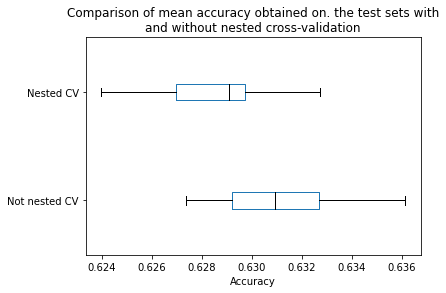

In [ ]:
import matplotlib.pyplot as plt

color = {"whiskers":"black", "medians":"black", "caps":"black"}
all_scores.plot.box(color=color, vert=False)
plt.xlabel("Accuracy")
_ = plt.title("Comparison of mean accuracy obtained on. the test sets with\n"
              "and without nested cross-validation")


We observe that the model's statistical performance with the nested cross-validation is not as good as the non-nested cross-validation.

As a conclusion, when optimizing parts of the machine learning pipeline (e.g. hyperparameter, transform, etc.), one needs to use nested cross-validation to evaluate the statistical performance of the predictive model. Otherwise, the results obtained without nested cross-validation are over-optimistic.

# Classification metrics

In [ ]:
import pandas as pd 

blood_transfusion = pd.read_csv("./datasets/blood_transfusion.csv")
data = blood_transfusion.drop(columns="Class")
target = blood_transfusion["Class"]

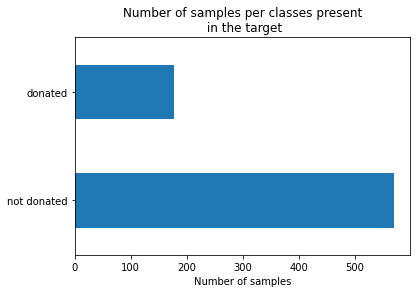

In [ ]:
import matplotlib.pyplot as plt 

target.value_counts().plot.barh()
plt.xlabel("Number of samples")
_ = plt.title("Number of samples per classes present\n in the target")

In [ ]:
from sklearn.model_selection import train_test_split 

data_train, data_test, target_train, target_test = train_test_split(
    data, target, shuffle=True, random_state=0, test_size=0.5
)

In [ ]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
classifier.fit(data_train, target_train)

LogisticRegression()

## Classifier predictions

For this reason, we will create a synthetic sample for a new potential donor: he/she donated blood twice in the past (1000 c.c. each time). The last time was 6 months ago, and the first time goes back to 20 months ago.



In [ ]:
new_donor = [[6, 2, 1000, 20]]

In [ ]:
classifier.predict(new_donor)

array(['not donated'], dtype=object)

With this information, our classifier predicts that this synthetic subject
is more likely to not donate blood again.

However, we cannot check whether the prediction is correct (we do not know
the true target value). That's the purpose of the testing set. First, we
predict whether a subject will give blood with the help of the trained
classifier.

In [ ]:
target_predicted = classifier.predict(data_test)
target_predicted[:5]

array(['not donated', 'not donated', 'not donated', 'not donated',
       'donated'], dtype=object)

## Accuracy as a baseline

In [ ]:
target_test == target_predicted

258     True
521    False
14     False
31     False
505     True
       ...  
665     True
100    False
422     True
615     True
743     True
Name: Class, Length: 374, dtype: bool

In the comparison above, a True value means that the value predicted by our classifier is identical to the real value, while a False means that our classifier made a mistake. 

In [ ]:
import numpy as np 
np.mean(target_test == target_predicted)

0.7780748663101604

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(target_test, target_predicted)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.778


In [ ]:
classifier.score(data_test, target_test)

0.7780748663101604

# Confusion matrix and derived metrics



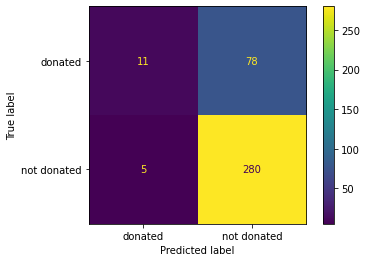

In [ ]:
from sklearn.metrics import plot_confusion_matrix 
_ = plot_confusion_matrix(classifier, data_test, target_test)

The in-diagonal numbers are related to predictions that were correct
while off-diagonal numbers are related to incorrect predictions
(misclassifications). We now know the four types of correct and erroneous
predictions:

* the top left corner are true positives (TP) and corresponds to people
  who gave blood and were predicted as such by the classifier;
* the bottom right corner are true negatives (TN) and correspond to
  people who did not give blood and were predicted as such by the
  classifier;
* the top right corner are false negatives (FN) and correspond to
  people who gave blood but were predicted to not have given blood;
* the bottom left corner are false positives (FP) and correspond to
  people who did not give blood but were predicted to have given blood.

Once we have split this information, we can compute metrics to highlight the
statistical performance of our classifier in a particular setting. For
instance, we could be interested in the fraction of people who really gave
blood when the classifier predicted so or the fraction of people predicted to
have given blood out of the total population that actually did so.

The former metric, known as the precision, is defined as TP / (TP + FP)
and represents how likely the person actually gave blood when the classifier
predicted that they did.
The latter, known as the recall, defined as TP / (TP + FN) and
assesses how well the classifier is able to correctly identify people who
did give blood.

In [ ]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(target_test, target_predicted, pos_label="donated")
recall = recall_score(target_test, target_predicted, pos_label="donated")

print(f"Precision score: {precision:.3f}")
print(f"Recall score: {recall:.3f}")

Precision score: 0.688
Recall score: 0.124


## The issue of class imbalance
At this stage, we could ask ourself a reasonable question. While the accuracy
did not look bad (i.e. 77%), the recall score is relatively low (i.e. 12%).

As we mentioned, precision and recall only focuses on samples predicted to be
positive, while accuracy takes both into account. In addition, we did not
look at the ratio of classes (labels). We could check this ratio in the
training set.

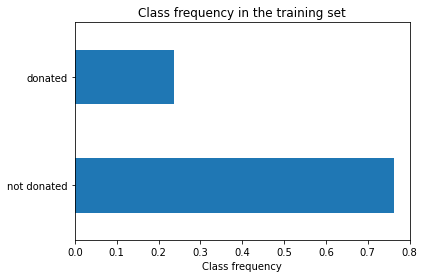

In [ ]:
target_train.value_counts(normalize=True).plot.barh()
plt.xlabel("Class frequency")
_ = plt.title("Class frequency in the training set")

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier(strategy="most_frequent")
dummy_classifier.fit(data_train, target_train)
print(f"Accuracy of the dummy classifier: "
      f"{dummy_classifier.score(data_test, target_test):.3f}")

Accuracy of the dummy classifier: 0.762


In [ ]:
from sklearn.metrics import balanced_accuracy_score

balanced_accuracy = balanced_accuracy_score(target_test, target_predicted)
print(f"Balanced accuracy: {balanced_accuracy:.3f}")

Balanced accuracy: 0.553


## Evaluation and different probability thresholds

In [ ]:
target_proba_predicted = pd.DataFrame(classifier.predict_proba(data_test),
                                      columns=classifier.classes_)
target_proba_predicted[:5]

,donated,not donated
0,0.271820,0.728180
1,0.451764,0.548236
2,0.445211,0.554789
3,0.441577,0.558423
4,0.870583,0.129417


In [ ]:
target_predicted = classifier.predict(data_test)
target_predicted[:5]

array(['not donated', 'not donated', 'not donated', 'not donated',
       'donated'], dtype=object)

In [ ]:
equivalence_pred_proba = (
    target_proba_predicted.idxmax(axis=1).to_numpy() == target_predicted
)
np.all(equivalence_pred_proba)

True

The default decision threshold (0.5) might not be the best threshold that
leads to optimal statistical performance of our classifier. In this case, one
can vary the decision threshold, and therefore the underlying prediction, and
compute the same statistics presented earlier. Usually, the two metrics
recall and precision are computed and plotted on a graph. Each metric plotted
on a graph axis and each point on the graph corresponds to a specific
decision threshold. Let's start by computing the precision-recall curve.

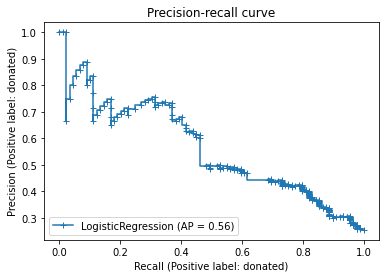

In [ ]:
from sklearn.metrics import plot_precision_recall_curve 

disp = plot_precision_recall_curve(
    classifier, data_test, target_test, pos_label="donated", marker="+"
)
_ = disp.ax_.set_title("Precision-recall curve")

<div class="admonition tip alert alert-warning">
<p class="first admonition-title" style="font-weight: bold;">Tip</p>
<p class="last">Scikit-learn will return a display containing all plotting element. Notably,
displays will expose a matplotlib axis, named <tt class="docutils literal">ax_</tt>, that can be used to add
new element on the axis.
You can refer to the documentation to have more information regarding the
<a class="reference external" href="https://scikit-learn.org/stable/visualizations.html#visualizations">visualizations in scikit-learn</a></p>
</div>

On this curve, each blue cross corresponds to a level of probability which we
used as a decision threshold. We can see that, by varying this decision
threshold, we get different precision vs. recall values.

A perfect classifier would have a precision of 1 for all recall values. A
metric characterizing the curve is linked to the area under the curve (AUC)
and is named average precision (AP). With an ideal classifier, the average
precision would be 1.

The precision and recall metric focuses on the positive class, however, one
might be interested in the compromise between accurately discriminating the
positive class and accurately discriminating the negative classes. The
statistics used for this are sensitivity and specificity. Sensitivity is just
another name for recall. However, specificity measures the proportion of
correctly classified samples in the negative class defined as: TN / (TN +
FP). Similar to the precision-recall curve, sensitivity and specificity are
generally plotted as a curve called the receiver operating characteristic
(ROC) curve. Below is such a curve:

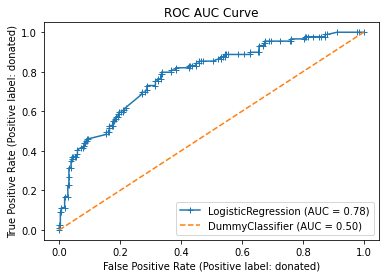

In [ ]:
from sklearn.metrics import plot_roc_curve 

disp = plot_roc_curve(
    classifier, data_test, target_test, pos_label="donated", marker="+"
)
disp = plot_roc_curve(
    dummy_classifier, data_test, target_test, pos_label="donated",
    color="tab:orange", linestyle="--", ax=disp.ax_
)
_ = disp.ax_.set_title("ROC AUC Curve")

This curve was built using the same principle as the precision-recall curve:
we vary the probability threshold for determining "hard" prediction and
compute the metrics. As with the precision-recall curve, we can compute the
area under the ROC (ROC-AUC) to characterize the statistical performance of
our classifier. However, it is important to observe that the lower bound of
the ROC-AUC is 0.5. Indeed, we show the statistical performance of a dummy
classifier (the orange dashed line) to show that even the worst statistical
performance obtained will be above this line.

# Exercise M7.02

In [ ]:
import pandas as pd

blood_transfusion = pd.read_csv("./datasets/blood_transfusion.csv")
data = blood_transfusion.drop(columns="Class")
target = blood_transfusion["Class"]

In [ ]:
from sklearn.tree import DecisionTreeClassifier 

tree = DecisionTreeClassifier()

Create a StratifiedKFold cross-validation object. Then use it inside the cross_val_score function to evaluate the decision tree. We will first use the accuracy as a score function. Explicitly use the scoring parameter of cross_val_score to compute the accuracy (even if this is the default score)

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold 
cv = StratifiedKFold(n_splits=10)
scores = cross_val_score(tree, data, target, cv=cv, scoring="accuracy")
print(f"Accuracy score: {scores.mean():.3f} +/- {scores.std():.3f}")

Accuracy score: 0.625 +/- 0.142


In [ ]:
scores = cross_val_score(tree, data, target, cv=cv, scoring="balanced_accuracy")
print(f"Balanced accuracy score: {scores.mean():.3f} +/- {scores.std():.3f}")

Balanced accuracy score: 0.514 +/- 0.110


In [ ]:
try:
  scores = cross_val_score(tree, data, target, cv=cv, scoring="precision")
except ValueError as exc:
  print(exc)

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:700: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py", line 687, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_scorer.py", line 88, in __call__
    *args, **kwargs)
  File "/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_scorer.py", line 243, in _score
    **self._kwargs)
  File "/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py", line 63, in inner_f
    return f(*args, **kwargs)
  File "/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py", line 1662, in precision_score
    zero_division=zero_division)
  File "/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py", line 63, in inner_f
   

We get an exception because the default scorer has its positive label set to one (pos_label=1), which is not our case (our positive label is “donated”). In this case, we need to create a scorer using the scoring function and the helper function make_scorer.

In [ ]:
from sklearn.metrics import make_scorer, precision_score 
precision = make_scorer(precision_score, pos_label="donated")

In [ ]:
scores = cross_val_score(tree, data, target, cv=cv, scoring=precision)
print(f"Precision score: {scores.mean():.3f} +/- {scores.std():.3f}")

Precision score: 0.245 +/- 0.176


cross_val_score will only compute a single score provided to the scoring parameter. The function cross_validate allows the computation of multiple scores by passing a list of string or scorer to the parameter scoring, which could be handy.

In [ ]:
from sklearn.model_selection import cross_validate 
scoring = ["accuracy", "balanced_accuracy"]

scores = cross_validate(tree, data, target, cv=cv, scoring=scoring)
scores

{'fit_time': array([0.00808883, 0.00417876, 0.00426555, 0.00571966, 0.00445414,
        0.00469041, 0.00393701, 0.00386596, 0.00381851, 0.00395203]),
 'score_time': array([0.00487065, 0.00296187, 0.00311041, 0.00339913, 0.00342631,
        0.00317502, 0.00299382, 0.00283813, 0.00292182, 0.00285101]),
 'test_accuracy': array([0.26666667, 0.50666667, 0.77333333, 0.54666667, 0.56      ,
        0.68      , 0.70666667, 0.77333333, 0.64864865, 0.74324324]),
 'test_balanced_accuracy': array([0.38450292, 0.46637427, 0.66081871, 0.37865497, 0.3874269 ,
        0.44736842, 0.55994152, 0.73684211, 0.48297214, 0.50309598])}

In [ ]:
import pandas as pd 
color = {"whiskers": "black", "medians": "black", "caps": "black"}

metrics = pd.DataFrame(
    [scores["test_accuracy"], scores["test_balanced_accuracy"]],
    index=["Accuracy", "Balanced accuracy"]
).T

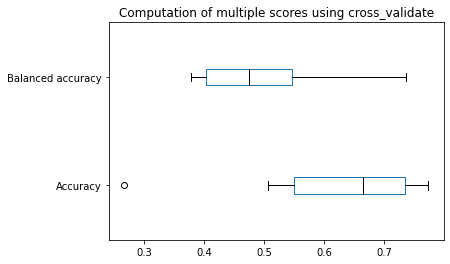

In [ ]:
import matplotlib.pyplot as plt

metrics.plot.box(vert=False, color=color)
_ = plt.title("Computation of multiple scores using cross_validate")

# Regression

In [ ]:
import pandas as pd 
import numpy as np 

ames_housing = pd.read_csv("./datasets/house_prices.csv")
data = ames_housing.drop(columns="SalePrice")
target = ames_housing["SalePrice"]
data = data.select_dtypes(np.number)
target /= 1000

In [ ]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, shuffle=True, random_state=0
)

Some machine learning models are designed to be solved as an optimization problem: minimizing an error (also known as the loss function) using a training set. A basic loss function used in regression is the mean squared error (MSE). Thus, this metric is sometimes used to evaluate the model since it is optimized by said model.

In [ ]:
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error 

regressor = LinearRegression() 
regressor.fit(data_train, target_train)
target_predicted = regressor.predict(data_train)

print(f"Mean squared error on the training set: "
      f"{mean_squared_error(target_train, target_predicted):.3f}")

Mean squared error on the training set: 996.902


In [ ]:
target_predicted = regressor.predict(data_test) 
print(f"Mean squared error on the testing set: "
      f"{mean_squared_error(target_test, target_predicted):.3f}")

Mean squared error on the testing set: 2064.736


In [ ]:
regressor.score(data_test, target_test)

0.6872520581075565

The $R^2$ score represents the proportion of variance of the target that is
explained by the independent variables in the model. The best score possible
is 1 but there is no lower bound. However, a model that predicts the expected
value of the target would get a score of 0.

In [ ]:
from sklearn.dummy import DummyRegressor

dummy_regressor = DummyRegressor(strategy="mean")
dummy_regressor.fit(data_train, target_train)
print(f"R2 score for a regressor predicting the mean:"
      f"{dummy_regressor.score(data_test, target_test):.3f}")

R2 score for a regressor predicting the mean:-0.000


In [ ]:
from sklearn.metrics import mean_absolute_error 

target_predicted = regressor.predict(data_test)
print(f"Mean absolute error: "
      f"{mean_absolute_error(target_test, target_predicted):.3f} k$")

Mean absolute error: 22.608 k$


By computing the mean absolute error, we can interpret that our model is predicting on average 22.6 k$ away from the true house price. A disadvantage of this metric is that the mean can be impacted by large error. For some applications, we might not want these large errors to have such a big influence on our metric. In this case we can use the median absolute error.

In [ ]:
from sklearn.metrics import median_absolute_error

print(f"Median absolute error: "
      f"{median_absolute_error(target_test, target_predicted):.3f} k$")

Median absolute error: 14.137 k$


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error 

print(f"Mean absolute percentage error: "
      f"{mean_absolute_percentage_error(target_test, target_predicted) * 100:.3f} %")

Mean absolute percentage error: 13.574 %


In [ ]:
predicted_actual = {
    "True values (k$)": target_test, "Predicted values (k$)": target_predicted}
predicted_actual = pd.DataFrame(predicted_actual)

In [ ]:
import matplotlib
matplotlib.__version__

'3.2.2'

AttributeError: ignored

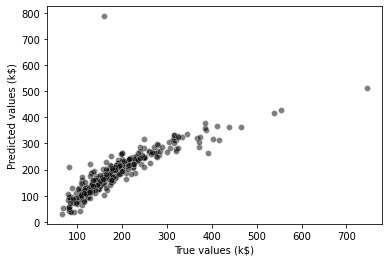

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=predicted_actual,
                x="True values (k$)", y="Predicted values (k$)",
                color="black", alpha=0.5)
plt.axline((0, 0), slope=1, label="Perfect fit") # since version 3.3 so gives an error
plt.axis('square')
_ = plt.title("Regression using a model without \ntarget transformation")

In [ ]:
from sklearn.preprocessing import QuantileTransformer 
from sklearn.compose import TransformedTargetRegressor

transformer = QuantileTransformer(
    n_quantiles=900, output_distribution="normal"
)
model_transformed_target = TransformedTargetRegressor(
    regressor=regressor, transformer=transformer
)
model_transformed_target.fit(data_train, target_train)
target_predicted = model_transformed_target.predict(data_test)

predicted_actual = {
    "True values (k$)": target_test, "Predicted values (k$)": target_predicted}
predicted_actual = pd.DataFrame(predicted_actual)

AttributeError: ignored

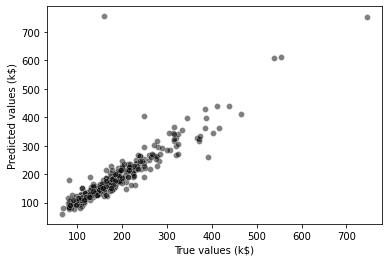

In [ ]:
sns.scatterplot(data=predicted_actual,
                x="True values (k$)", y="Predicted values (k$)",
                color="black", alpha=0.5)
plt.axline((0, 0), slope=1, label="Perfect fit")
plt.axis('square')
plt.legend()
_ = plt.title("Regression using a model that\n transform the target before "
              "fitting")

# Exercise M7.03

In [ ]:
import pandas as pd
import numpy as np

ames_housing = pd.read_csv("../datasets/house_prices.csv")
data = ames_housing.drop(columns="SalePrice")
target = ames_housing["SalePrice"]
data = data.select_dtypes(np.number)
target /= 1000

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, data, target, cv=10, scoring="r2")
print(f"R2 score: {scores.mean():.3f} +/- {scores.std():.3f}")

R2 score: 0.794 +/- 0.103


In [ ]:
scores = cross_val_score(model, data, target, cv=10,
                         scoring="neg_mean_absolute_error")
errors = -scores 
print(f"Mean absolute error: "
      f"{errors.mean():.3f} k$ +/- {errors.std():.3f}")

Mean absolute error: 21.892 k$ +/- 2.225


The scoring parameter in scikit-learn expects score. It means that the higher the values, and the smaller the errors are, the better the model is. Therefore, the error should be multiplied by -1. That’s why the string given the scoring starts with neg_ when dealing with metrics which are errors.

Finally, use the cross_validate function and compute multiple scores/errors at once by passing a list of scorers to the scoring parameter. You can compute the R2 score and the mean absolute error for instance.

In [ ]:
from sklearn.model_selection import cross_validate 
scoring = ["r2", "neg_mean_absolute_error"]
cv_results = cross_validate(model, data, target, scoring=scoring)

In [ ]:
import pandas as pd 
scores = {"R2": cv_results["test_r2"],
          "MSE": -cv_results["test_neg_mean_absolute_error"]}
scores = pd.DataFrame(scores)
scores

,R2,MSE
0,0.848721,21.256799
1,0.816374,22.084083
2,0.813513,22.113367
3,0.814138,20.448279
4,0.637473,24.370341


# Wrap-up quiz 7

In [ ]:
import pandas as pd 

cycling = pd.read_csv("./datasets/bike_rides.csv", index_col=0, parse_dates=True)
cycling.index.name = ""
target_name = "power"
data, target = cycling.drop(columns=target_name), cycling[target_name]
data.head()

,heart-rate,cadence,speed,acceleration,slope
,,,,,
2020-08-18 14:43:19,102.0,64.0,4.325,0.0880,-0.033870
2020-08-18 14:43:20,103.0,64.0,4.336,0.0842,-0.033571
2020-08-18 14:43:21,105.0,66.0,4.409,0.0234,-0.033223
2020-08-18 14:43:22,106.0,66.0,4.445,0.0016,-0.032908
2020-08-18 14:43:23,106.0,67.0,4.441,0.1144,0.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38254 entries, 2020-08-18 14:43:19 to 2020-09-13 14:56:01
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   heart-rate    38254 non-null  float64
 1   cadence       38254 non-null  float64
 2   speed         38254 non-null  float64
 3   acceleration  38254 non-null  float64
 4   slope         38254 non-null  float64
dtypes: float64(5)
memory usage: 1.8 MB


In [ ]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, shuffle=True, random_state=0
)

In [ ]:
import numpy as np 
alpha = np.arctan(data["slope"])
fourth = np.sin(alpha) * data["speed"]
fourth.mean()

-0.0027097096125663312

In [ ]:
import numpy as np 

# build the data matrix
data_linear_model = pd.concat(
    {
     "speed^3":data["speed"] ** 3,
     "speed": data["speed"],
     "speed*sin(alpha)": data["speed"] * np.sin(np.arctan(data["slope"])),
     "speed*acceleration": data["speed"] * data["acceleration"].clip(lower=0)
    }, axis=1
)
data_linear_model.mean()["speed*sin(alpha)"]

-0.0027097096125663312

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV 
from sklearn.model_selection import ShuffleSplit, cross_validate
from sklearn.pipeline import make_pipeline

linear_model = make_pipeline(StandardScaler(), RidgeCV())

cv = ShuffleSplit(n_splits=4, random_state=0)
cv_results_linear_model = cross_validate(
    linear_model, data_linear_model, target, cv=cv,
    scoring="neg_mean_absolute_error",
    return_estimator=True, return_train_score=True
)
errors = -cv_results_linear_model["test_score"]
print(f"MAE on test sets:\n{errors}\n",
      f"mean +/- std: {errors.mean():.3f} +/- {errors.std():.3f} Watts")

MAE on test sets:
[73.23006461 72.1311734  72.89061823 71.2370263 ]
 mean +/- std: 72.372 +/- 0.767 Watts


In [ ]:
for estimator in cv_results_linear_model["estimator"]:
  print(estimator[-1].coef_)

[ 5.66427806 32.84904152 80.08105928 10.85618779]
[ 5.68897463 32.83434375 80.99005594 11.34425   ]
[ 6.28736152 32.19112942 80.92397865 11.23297157]
[ 6.18278112 32.4035743  80.61344415 11.27427489]


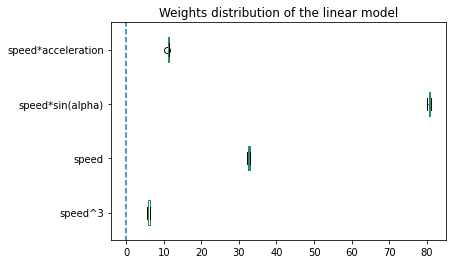

In [ ]:
import matplotlib.pyplot as plt
coefs = [
    estimator[-1].coef_ for estimator in cv_results_linear_model["estimator"]]
coefs = pd.DataFrame(coefs, columns=data_linear_model.columns)

ax = coefs.plot.box(vert=False)
ax.axvline(0, -1, 1, linestyle="--")
_ = plt.title("Weights distribution of the linear model")

In [ ]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor

hist_model = HistGradientBoostingRegressor(
  max_iter=1000, early_stopping=True, random_state=0
)

cv = ShuffleSplit(n_splits=4, random_state=0)
cv_results_hist_model = cross_validate(
    hist_model, data, target, cv=cv,
    scoring="neg_mean_absolute_error",
    return_estimator=True, return_train_score=True, n_jobs=2)
errors = -cv_results_hist_model["test_score"]
print(f"MAE on test sets:\n{errors}\n",
      f"mean +/- std: {errors.mean():.3f} +/- {errors.std():.3f} Watts")

MAE on test sets:
[44.71263363 43.9783554  42.92460634 43.10264111]
 mean +/- std: 43.680 +/- 0.718 Watts


In [ ]:
errors = -cv_results_linear_model["train_score"]
print(f"Linear model - MAE on train sets:\n {errors}\n",
      f"mean +/- std: {errors.mean():.3f} +/- {errors.std():.3f} Watts")
errors = -cv_results_linear_model["test_score"]
print(f"Linear model - MAE on test sets:\n {errors}\n",
      f"mean +/- std: {errors.mean():.3f} +/- {errors.std():.3f} Watts")

errors = -cv_results_hist_model["train_score"]
print(f"Histogram GBDT - MAE on train sets:\n {errors}\n",
      f"mean +/- std: {errors.mean():.3f} +/- {errors.std():.3f} Watts")
errors = -cv_results_hist_model["test_score"]
print(f"Histogram GBDT - MAE on test sets:\n {errors}\n",
      f"mean +/- std: {errors.mean():.3f} +/- {errors.std():.3f} Watts")

Linear model - MAE on train sets:
 [72.35634493 72.51703894 72.42974777 72.6121094 ]
 mean +/- std: 72.479 +/- 0.096 Watts
Linear model - MAE on test sets:
 [73.23006461 72.1311734  72.89061823 71.2370263 ]
 mean +/- std: 72.372 +/- 0.767 Watts
Histogram GBDT - MAE on train sets:
 [41.09640232 40.67363765 38.79560993 39.40709345]
 mean +/- std: 39.993 +/- 0.930 Watts
Histogram GBDT - MAE on test sets:
 [44.71263363 43.9783554  42.92460634 43.10264111]
 mean +/- std: 43.680 +/- 0.718 Watts


With the histogram gradient boosting, the testing error is higher than the training error. This symptomatic of a model capable of overfitting. The testing and training error of the linear model are very close. However, the errors are much higher than the histogram gradient boosting. The linear model is clearly underfitting.


I misunderstood...this result is ERROR based!

## Question 6

In [ ]:
pd.DataFrame(data.index.date).value_counts()

2020-08-26    10324
2020-08-18    10222
2020-08-20    10055
2020-09-13     7653
dtype: int64

In [ ]:
import numpy as np 
unique_ride_dates = np.unique(cycling.index.date)
print(f"There are {len(unique_ride_dates)} bike rides")

There are 4 bike rides


## Question 7

In [ ]:
unique_ride_dates

array([datetime.date(2020, 8, 18), datetime.date(2020, 8, 20),
       datetime.date(2020, 8, 26), datetime.date(2020, 9, 13)],
      dtype=object)

In [ ]:
group = unique_ride_dates
group

array([datetime.date(2020, 8, 18), datetime.date(2020, 8, 20),
       datetime.date(2020, 8, 26), datetime.date(2020, 9, 13)],
      dtype=object)

In [ ]:
pd.factorize(group)

(array([0, 1, 2, 3]),
 array([datetime.date(2020, 8, 18), datetime.date(2020, 8, 20),
        datetime.date(2020, 8, 26), datetime.date(2020, 9, 13)],
       dtype=object))

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut 

groups, _ = pd.factorize(data_linear_model.index.date)
cv = LeaveOneGroupOut()

cv_results_linear_model = cross_validate(
    linear_model, data_linear_model, target, groups=groups, cv=cv,
    scoring="neg_mean_absolute_error", return_estimator=True,
    return_train_score=True, n_jobs=2
)
cv_results_hgbdt_model = cross_validate(
    hist_model, data, target, cv=cv, groups=groups,
    scoring="neg_mean_absolute_error", return_estimator=True,
    return_train_score=True, n_jobs=2
)

errors = -cv_results_linear_model["train_score"]
print(f"Linear model - MAE on train sets:\n {errors}\n",
      f"mean +/- std: {errors.mean():.3f} +/- {errors.std():.3f} Watts")
errors = -cv_results_linear_model["test_score"]
print(f"Linear model - MAE on test sets:\n {errors}\n",
      f"mean +/- std: {errors.mean():.3f} +/- {errors.std():.3f} Watts")

errors = -cv_results_hgbdt_model["train_score"]
print(f"Histogram GBDT - MAE on train sets:\n {errors}\n",
      f"mean +/- std: {errors.mean():.3f} +/- {errors.std():.3f} Watts")
errors = -cv_results_hgbdt_model["test_score"]
print(f"Histogram GBDT - MAE on test sets:\n {errors}\n",
      f"mean +/- std: {errors.mean():.3f} +/- {errors.std():.3f} Watts")

Linear model - MAE on train sets:
 [72.4317474  72.28702403 68.96505889 75.31150408]
 mean +/- std: 72.249 +/- 2.247 Watts
Linear model - MAE on test sets:
 [72.44062969 73.32064854 81.30750799 64.99031478]
 mean +/- std: 73.015 +/- 5.779 Watts
Histogram GBDT - MAE on train sets:
 [39.49957639 40.75980377 36.57874345 41.18176443]
 mean +/- std: 39.505 +/- 1.799 Watts
Histogram GBDT - MAE on test sets:
 [47.70496008 48.03461081 53.82834906 47.95888698]
 mean +/- std: 49.382 +/- 2.570 Watts


ShuffleSplit is giving optimmistic results for the gradient-boosting model here since train error are very similar on both cross-validation strategies, but LeaveOneGroupOut is higher on test sets. So ShuffleSplit is optimistic but the number itself is very similar so I didn't think it's OVER-optimistic.

## Question 10

In [ ]:
cv = LeaveOneGroupOut()
train_indices, test_indices = list(cv.split(data, target, groups=groups))[0]

data_linear_model_train = data_linear_model.iloc[train_indices]
data_linear_model_test = data_linear_model.iloc[test_indices]

data_train = data.iloc[train_indices]
data_test = data.iloc[test_indices]

target_train = target.iloc[train_indices]
target_test = target.iloc[test_indices]


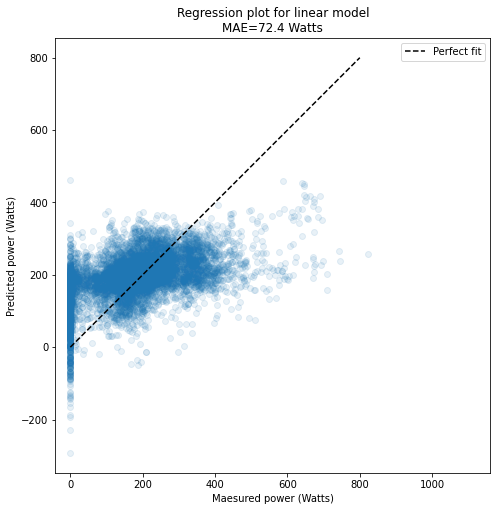

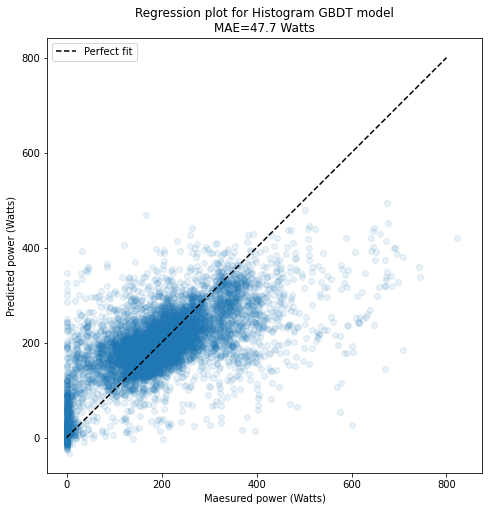

In [ ]:
from sklearn.metrics import mean_absolute_error
linear_model.fit(data_linear_model_train, target_train)
target_predicted_linear_model = linear_model.predict(data_linear_model_test)

hist_model.fit(data_train, target_train)
target_predicted_hist_model = hist_model.predict(data_test)

# computer errors
mae_linear_model = mean_absolute_error(target_test, target_predicted_linear_model)
mae_hist_model = mean_absolute_error(target_test, target_predicted_hist_model)

# plots
plt.figure(figsize=(8,8))
plt.scatter(target_test, target_predicted_linear_model, alpha=0.1)
plt.plot([0, 800], [0, 800], color="black", linestyle="--", label="Perfect fit")
plt.legend()
plt.axis("square")
plt.xlabel("Maesured power (Watts)")
plt.ylabel("Predicted power (Watts)")
_ = plt.title(f"Regression plot for linear model\n"
              f"MAE={mae_linear_model:.1f} Watts")

plt.figure(figsize=(8,8))
plt.scatter(target_test, target_predicted_hist_model, alpha=0.1)
plt.plot([0, 800], [0, 800], color="black", linestyle="--", label="Perfect fit")
plt.legend()
plt.axis("square")
plt.xlabel("Maesured power (Watts)")
plt.ylabel("Predicted power (Watts)")
_ = plt.title(f"Regression plot for Histogram GBDT model\n"
              f"MAE={mae_hist_model:.1f} Watts")


In [ ]:
time_slice = slice("2020-08-18 17:00:00", "2020-08-18 17:05:00")

data_test_linear_model_subset = data_linear_model_test[time_slice]
data_test_subset = data_test[time_slice]
target_test_subset = target_test[time_slice]

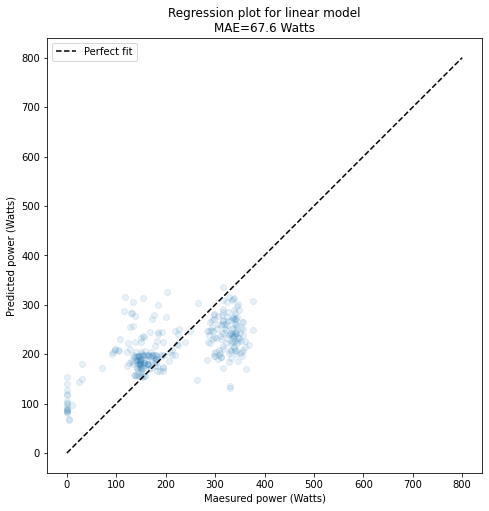

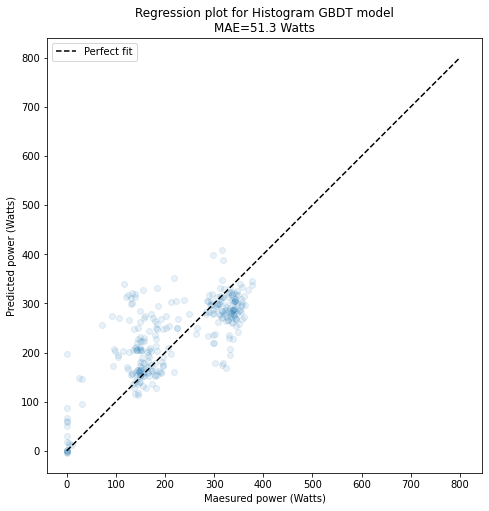

In [ ]:
target_predicted_linear_model = linear_model.predict(data_test_linear_model_subset)
target_predicted_hist_model = hist_model.predict(data_test_subset)

# computer errors
mae_linear_model = mean_absolute_error(target_test_subset, target_predicted_linear_model)
mae_hist_model = mean_absolute_error(target_test_subset, target_predicted_hist_model)

# plots
plt.figure(figsize=(8,8))
plt.scatter(target_test_subset, target_predicted_linear_model, alpha=0.1)
plt.plot([0, 800], [0, 800], color="black", linestyle="--", label="Perfect fit")
plt.legend()
plt.axis("square")
plt.xlabel("Maesured power (Watts)")
plt.ylabel("Predicted power (Watts)")
_ = plt.title(f"Regression plot for linear model\n"
              f"MAE={mae_linear_model:.1f} Watts")

plt.figure(figsize=(8,8))
plt.scatter(target_test_subset, target_predicted_hist_model, alpha=0.1)
plt.plot([0, 800], [0, 800], color="black", linestyle="--", label="Perfect fit")
plt.legend()
plt.axis("square")
plt.xlabel("Maesured power (Watts)")
plt.ylabel("Predicted power (Watts)")
_ = plt.title(f"Regression plot for Histogram GBDT model\n"
              f"MAE={mae_hist_model:.1f} Watts")

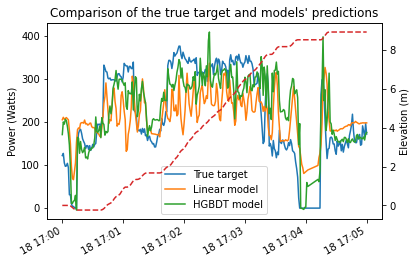

In [ ]:
# make the plot
ax = target_test_subset.plot(label="True target")
ax.plot(target_test_subset.index, target_predicted_linear_model,
        label="Linear model")
ax.plot(target_test_subset.index, target_predicted_hist_model, label="HGBDT model")
ax.set_ylabel("Power (Watts)")
plt.legend()

# In addition, we add the elevation to show that the data were acquired in a
# hill. This part of the answer was optional.
ax_elevation = ax.twinx()
ax_elevation.plot(target_test_subset.index, data_test_subset["slope"].cumsum(),
                  color="tab:red", linestyle="--")
ax_elevation.set_ylabel("Elevation (m)")

_ = plt.title("Comparison of the true target and models' predictions")